# Import modules

In [1]:
from matplotlib.pyplot import *
from numpy             import *
from pandas            import *
from pyatomdb          import *
from seaborn           import *

# Setup Seaborn

In [2]:
set        ()
set_context("notebook")

# Si01 Level

In [3]:
Xstar_Si01_Level = read_csv("/Users/tanimoto/github/atomicdatabase/database/xstar/Si/Si01_Level.tsv",sep="\t")
Xstar_Si01_Level = Xstar_Si01_Level.drop(columns="Unnamed: 0")
Xstar_Si01_Level.head()

,Z,Ion,Electron,Level,N,L,2S+1,2J+1,Energy,Potential,Configuration
0,14,105,1,1,1,0,2,2,0.000,2673.0,1s1.2S_1/2
1,14,105,1,2,2,1,2,2,2004.328,2673.0,1s0.2p1.2P_1/2
2,14,105,1,3,2,1,2,4,2006.082,2673.0,1s0.2p1.2P_3/2
3,14,105,1,4,2,0,2,2,2004.393,2673.0,1s0.2s1.2S_1/2
4,14,105,1,5,3,1,2,2,2376.108,2673.0,1s0.3p1.2P_1/2


In [4]:
Level            = []
Energy           = []
NL               = []
J                = []
Configuration    = []
Si01_Translation = {}

with open("/Users/tanimoto/github/atomicdatabase/database/monaco/Si/Si01.en") as file:
    for line in file.readlines():
        line = line.split()
        for n in range(len(Xstar_Si01_Level.index)-1):
            if line[5]==str(100*Xstar_Si01_Level["N"][n]+Xstar_Si01_Level["L"][n]) and line[6]==str(Xstar_Si01_Level["2J+1"][n]-1):
                Level                    += [Xstar_Si01_Level["Level"][n]]
                Energy                   += [float(line[3])]
                NL                       += [line[5]]
                J                        += [line[6]]
                Configuration            += [" ".join(line[7:])]
                Si01_Translation[line[1]] = str(Xstar_Si01_Level["Level"][n])

Monaco_Si01_Level = DataFrame({"Level":Level, "Energy":Energy, "NL":NL, "2J":J, "Configuration":Configuration})
Monaco_Si01_Level = Monaco_Si01_Level.sort_values(["Level"]).reset_index(drop=True)
Monaco_Si01_Level

,Level,Energy,NL,2J,Configuration
0,1,0.00000,100,1,1*1 1s1 1s+1(1)1
1,2,2004.34588,201,1,2*1 2p1 2p-1(1)1
2,3,2006.10069,201,3,2*1 2p1 2p+1(3)3
3,4,2004.40893,200,1,2*1 2s1 2s+1(1)1
4,5,2376.12663,301,1,3*1 3p1 3p-1(1)1
5,6,2376.64668,301,3,3*1 3p1 3p+1(3)3
6,7,2376.14551,300,1,3*1 3s1 3s+1(1)1
7,8,2376.64578,302,3,3*1 3d1 3d-1(3)3
8,9,2376.81810,302,5,3*1 3d1 3d+1(5)5
9,10,2506.17845,401,1,4*1 4p1 4p-1(1)1


In [5]:
Si01_Level_Index  = []
Si01_Level_Energy = []

for i in range(len(Xstar_Si01_Level.index)):
    for j in range(len(Monaco_Si01_Level.index)):
        if Xstar_Si01_Level["Level"][i]==Monaco_Si01_Level["Level"][j]:
            Si01_Level_Index  += [Xstar_Si01_Level["Level"][i]]
            Si01_Level_Energy += [Xstar_Si01_Level["Energy"][i]-Monaco_Si01_Level["Energy"][j]]

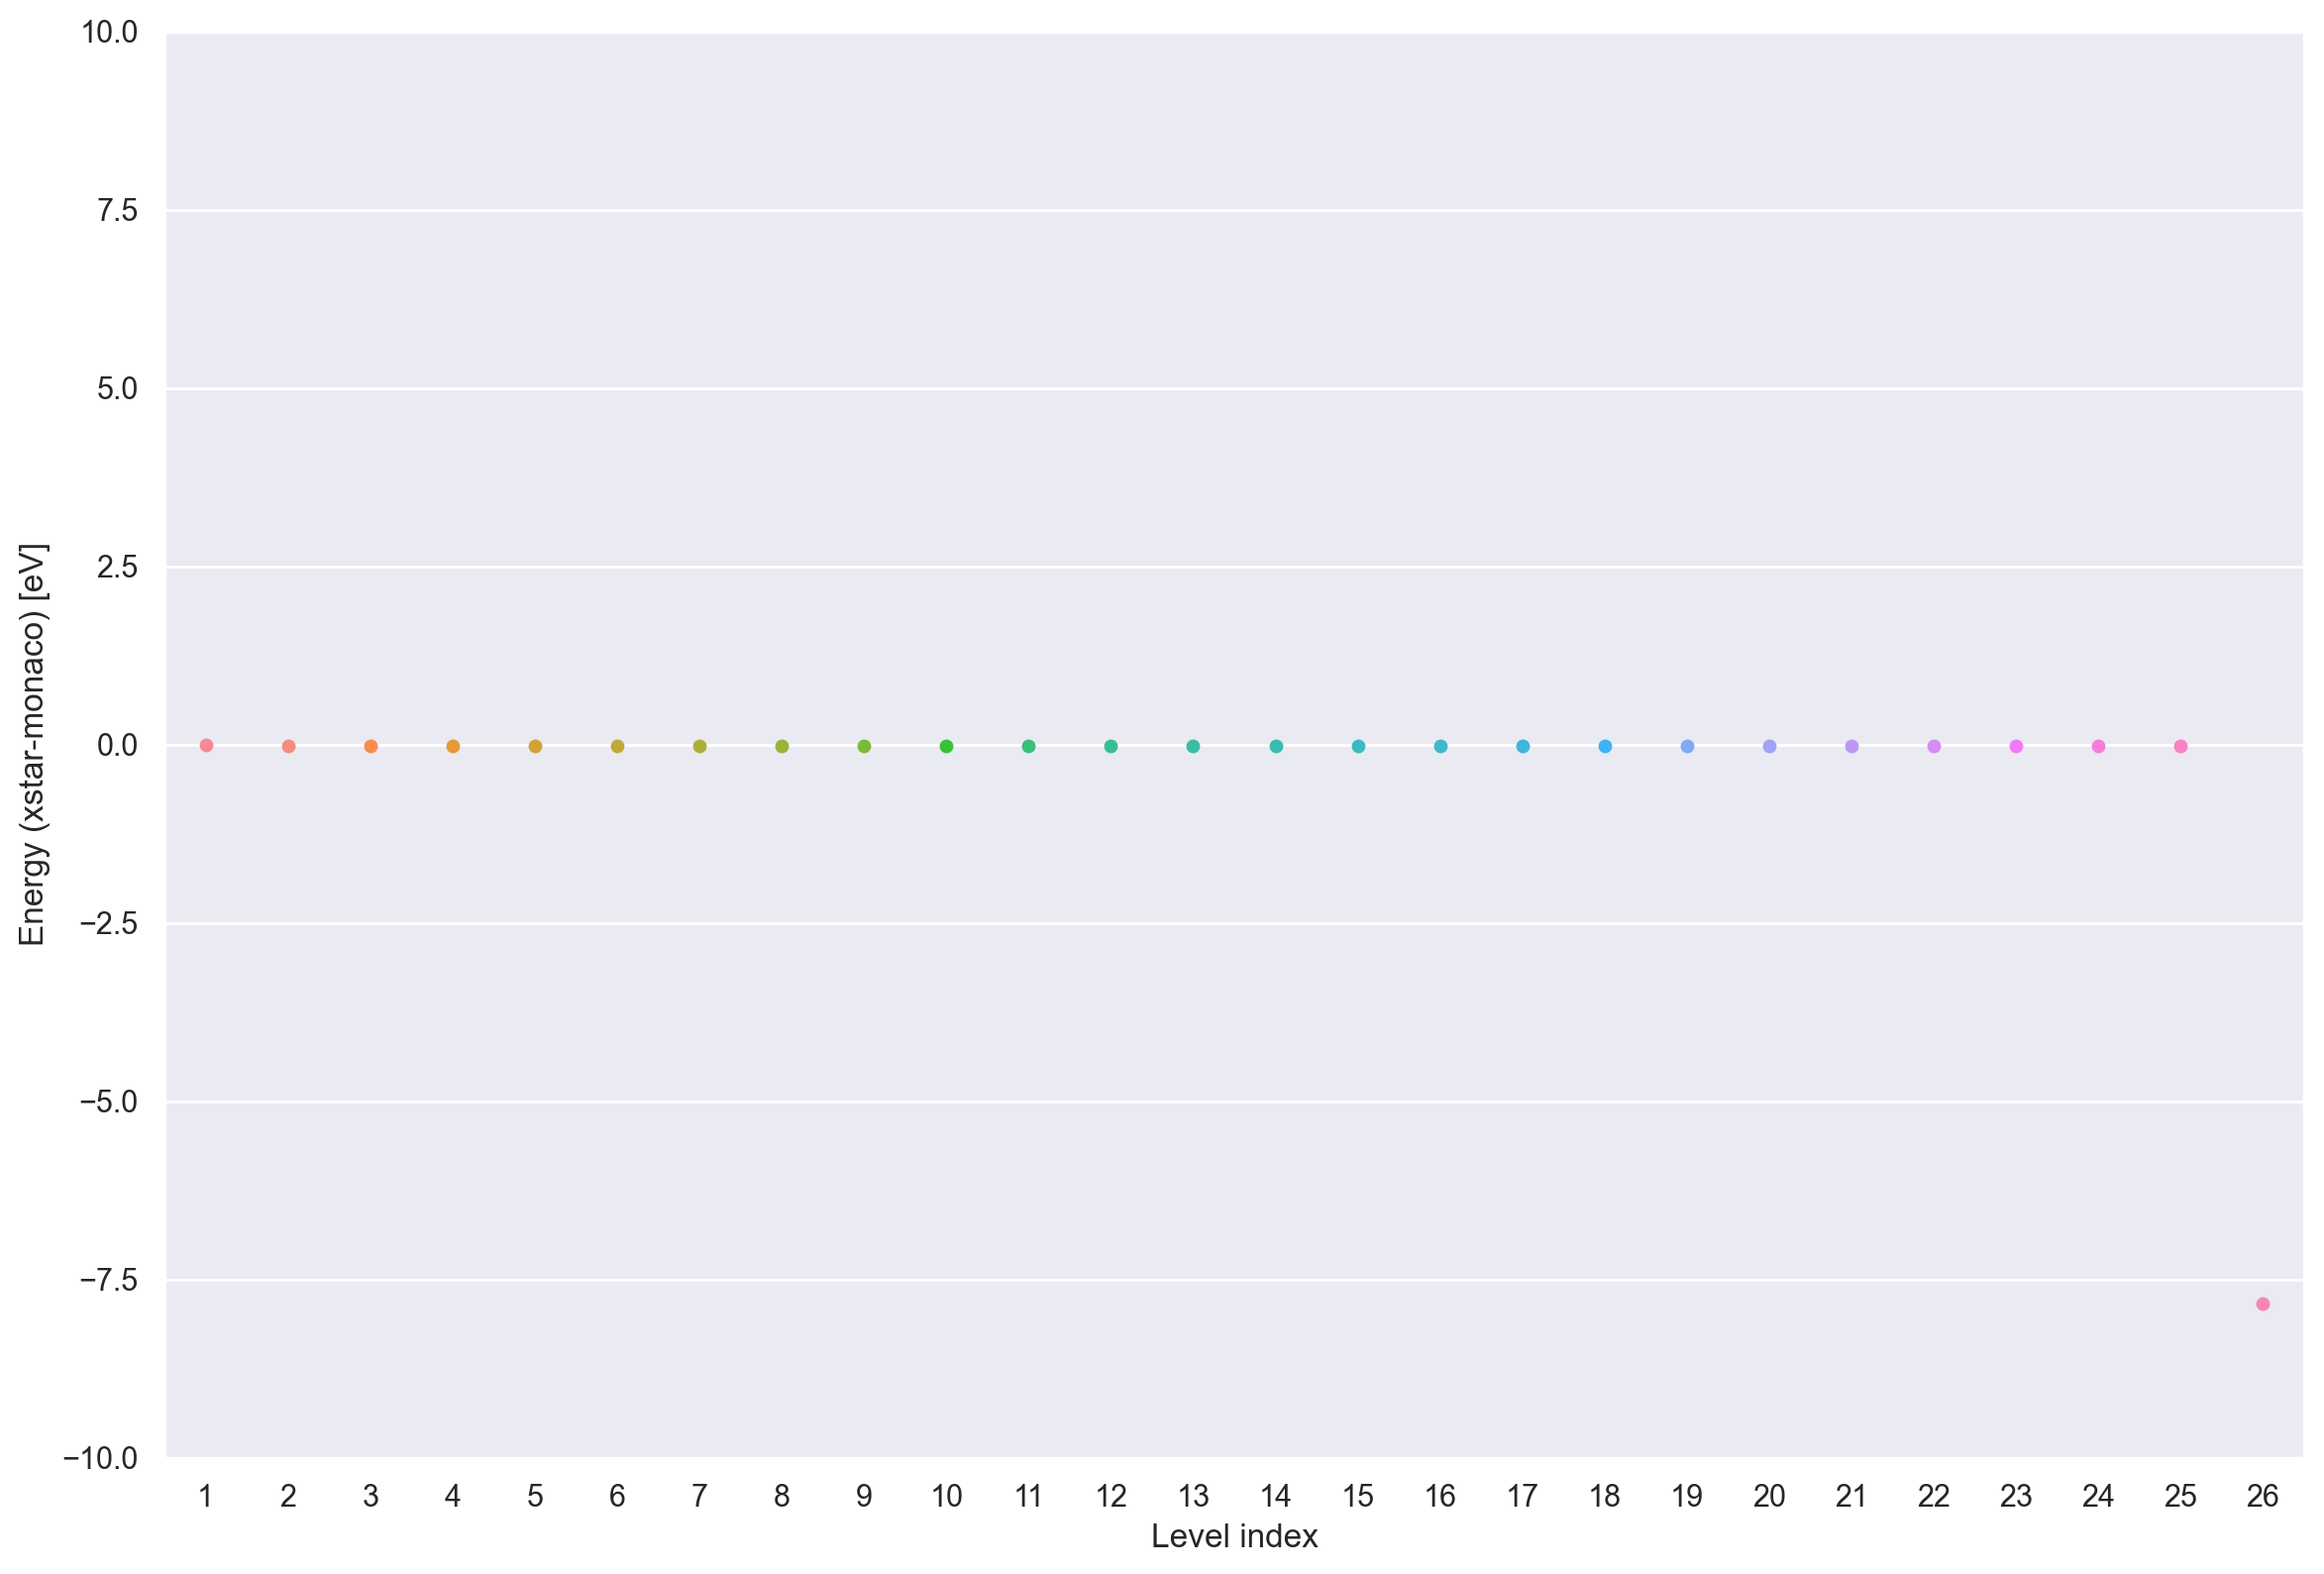

In [6]:
fi     = figure(figsize=(12,8),dpi=200)
subplots_adjust(left=0.075, bottom=0.075, right=0.975, top=0.975)
axis           ([0e+0,3e+1,-1e+1,+1e+1])
swarmplot      (x=Si01_Level_Index, y=Si01_Level_Energy)
xlabel         ("Level index")
ylabel         ("Energy (xstar-monaco) [eV]")
savefig        ("/Users/tanimoto/github/atomicdatabase/figure/00.png")

# Si01 Transition

In [7]:
Xstar_Si01_Transition = read_csv("/Users/tanimoto/github/atomicdatabase/database/xstar/Si/Si01_Transition01.tsv",sep="\t")
Xstar_Si01_Transition = Xstar_Si01_Transition.drop(columns="Unnamed: 0")
Xstar_Si01_Transition

,Z,Ion,Initial Level,Final Level,Energy,Strength,Rate
0,14,105,2,1,2004.25900,0.0,2.406770e+13
1,14,105,3,1,2006.01400,0.0,2.406770e+13
2,14,105,5,1,2376.02700,0.0,6.425310e+12
3,14,105,5,4,371.70220,0.0,8.623930e+11
4,14,105,6,1,2376.54700,0.0,6.425310e+12
...,...,...,...,...,...,...,...
128,14,105,30,16,84.67897,0.0,5.273790e+10
129,14,105,30,22,24.69472,0.0,4.247730e+10
130,14,105,30,23,24.67612,0.0,4.247730e+10
131,14,105,31,24,24.67612,0.0,6.318930e+10


In [8]:
Initial_Level = []
Final_Level   = []
Energy        = []
Strength      = []
Rate          = []

with open("/Users/tanimoto/github/atomicdatabase/database/monaco/Si/Si01.tr") as file:
    for line in file.readlines():
        line = line.split()
        if line[0] in Si01_Translation.keys() and line[2] in Si01_Translation.values():
            Initial_Level += [int(Si01_Translation[line[0]])]
            Final_Level   += [int(Si01_Translation[line[2]])]
            Energy        += [float(line[4])]
            Strength      += [float(line[5])]
            Rate          += [float(line[6])]

Monaco_Si01_Transition = DataFrame({"Initial Level":Initial_Level, "Final Level":Final_Level, "Energy":Energy, "Strength":Strength, "Rate":Rate})
Monaco_Si01_Transition = Monaco_Si01_Transition.sort_values(["Initial Level", "Final Level"]).reset_index(drop=True)
Monaco_Si01_Transition

,Initial Level,Final Level,Energy,Strength,Rate
0,3,2,1.754814,3.810633e-07,2.545883e+01
1,3,4,1.691762,3.793102e-03,2.355334e+05
2,4,2,0.063051,7.031455e-05,1.212951e+01
3,5,4,371.717700,1.448457e-01,8.684433e+11
4,6,4,372.237800,2.864270e-01,8.610614e+11
...,...,...,...,...,...
90,26,6,222.365900,3.097575e-03,1.329223e+10
91,26,10,92.834170,1.232942e-02,4.610709e+09
92,26,11,92.614830,1.259604e-02,9.376359e+09
93,26,17,32.669240,7.448735e-02,3.449610e+09


In [9]:
Si01_Transition_Index    = []
Si01_Transition_Energy   = []
Si01_Transition_Strength = []
Si01_Transition_Rate     = []

for i in range(len(Xstar_Si01_Transition.index)):
    for j in range(len(Monaco_Si01_Transition.index)):
        if Xstar_Si01_Transition["Initial Level"][i]==Monaco_Si01_Transition["Initial Level"][j] and Xstar_Si01_Transition["Final Level"][i]==Monaco_Si01_Transition["Final Level"][j]:
            Si01_Transition_Index    += ["{0:04d}".format(100*Xstar_Si01_Transition["Initial Level"][i]+Xstar_Si01_Transition["Final Level"][i])]
            Si01_Transition_Energy   += [Xstar_Si01_Transition["Energy"][i]-Monaco_Si01_Transition["Energy"][j]]
            Si01_Transition_Strength += [Xstar_Si01_Transition["Strength"][i]-Monaco_Si01_Transition["Strength"][j]]
            Si01_Transition_Rate     += [Xstar_Si01_Transition["Rate"][i]/Monaco_Si01_Transition["Rate"][j]]

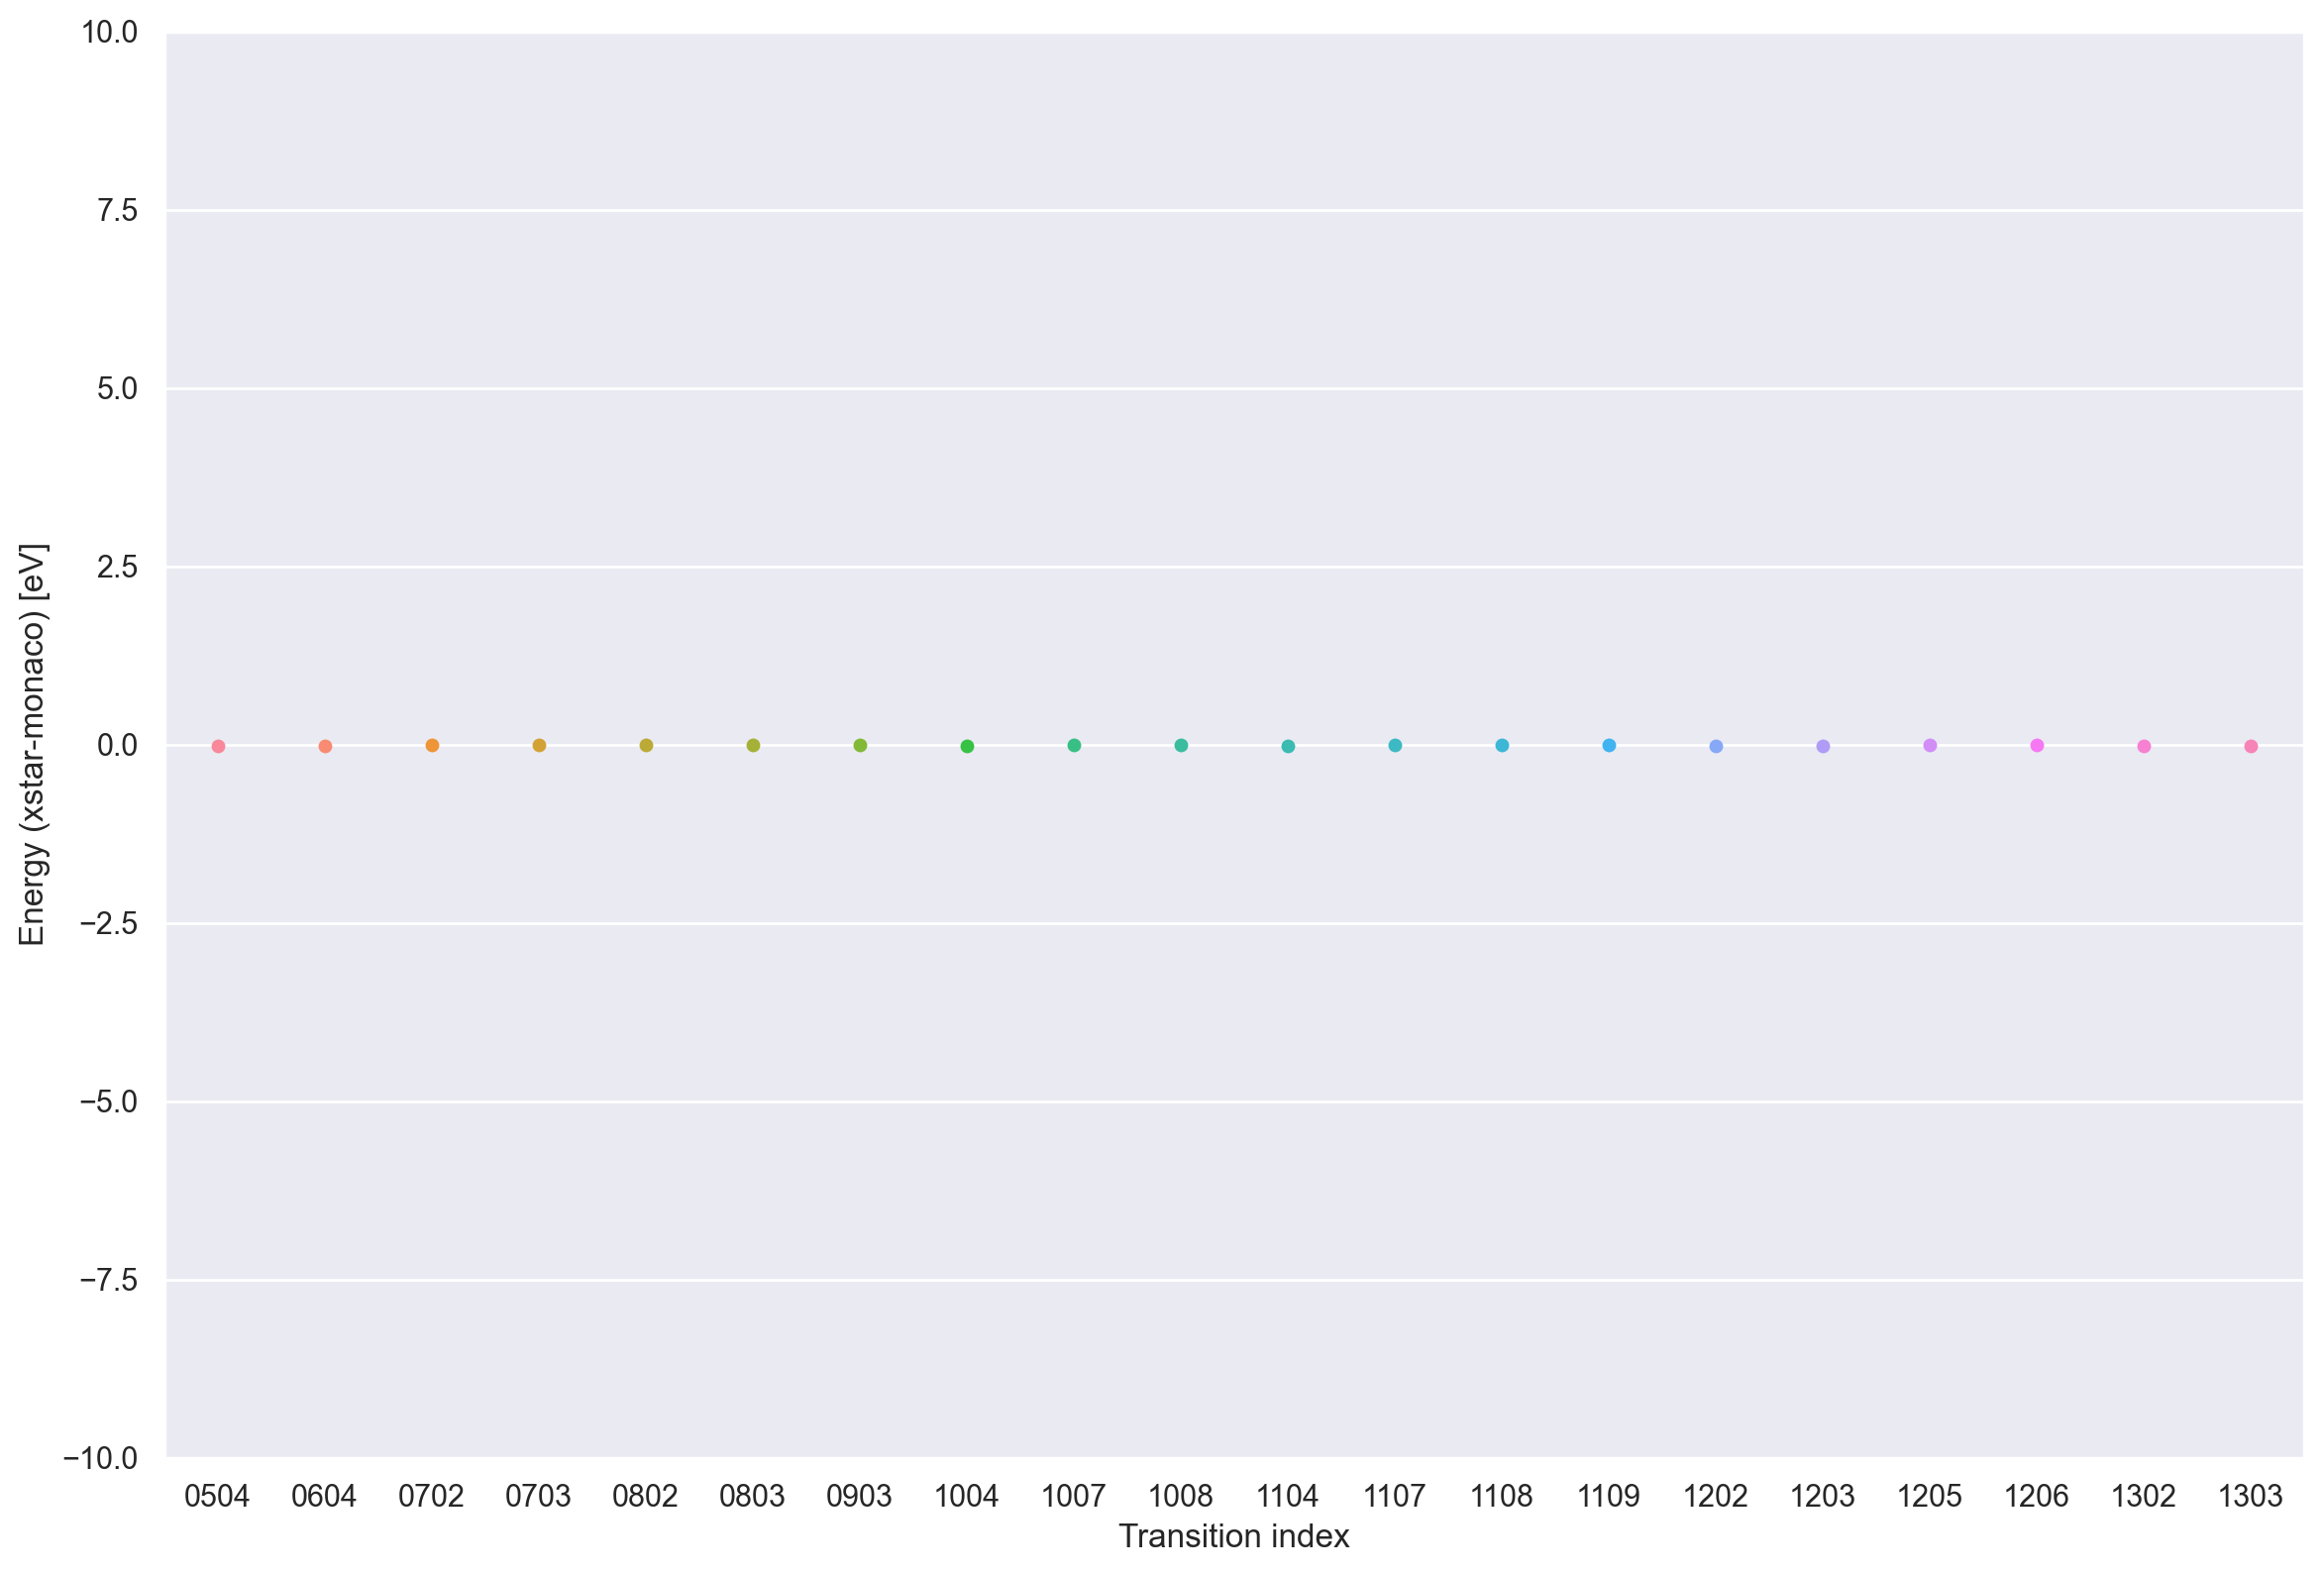

In [10]:
fi     = figure(figsize=(12,8),dpi=200)
subplots_adjust(left=0.075, bottom=0.075, right=0.975, top=0.975)
axis           ([0e+0,3e+3,-1e+1,+1e+1])
swarmplot      (x=Si01_Transition_Index[0:20], y=Si01_Transition_Energy[0:20])
xlabel         ("Transition index")
ylabel         ("Energy (xstar-monaco) [eV]")
savefig        ("/Users/tanimoto/github/atomicdatabase/figure/01.png")

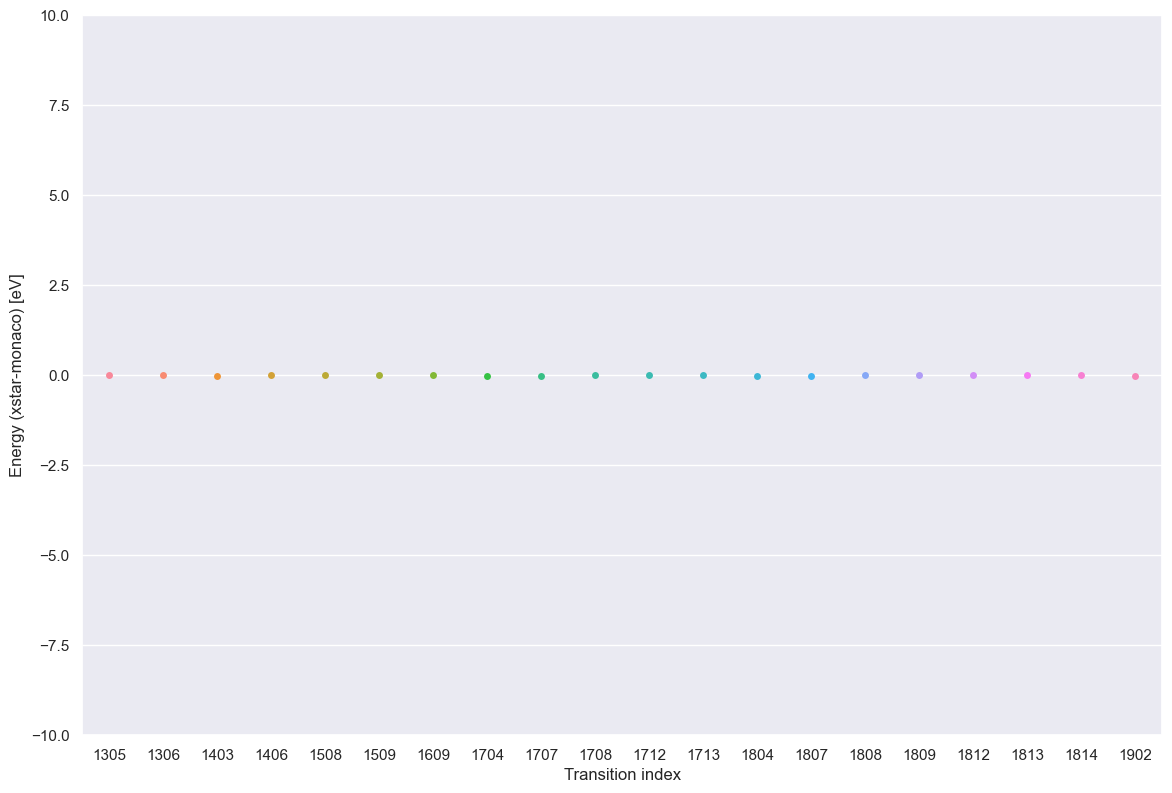

In [11]:
fi     = figure(figsize=(12,8),dpi=100)
subplots_adjust(left=0.075, bottom=0.075, right=0.975, top=0.975)
axis           ([0e+0,3e+3,-1e+1,+1e+1])
swarmplot      (x=Si01_Transition_Index[20:40], y=Si01_Transition_Energy[20:40])
xlabel         ("Transition index")
ylabel         ("Energy (xstar-monaco) [eV]")
savefig        ("/Users/tanimoto/github/atomicdatabase/figure/02.png")

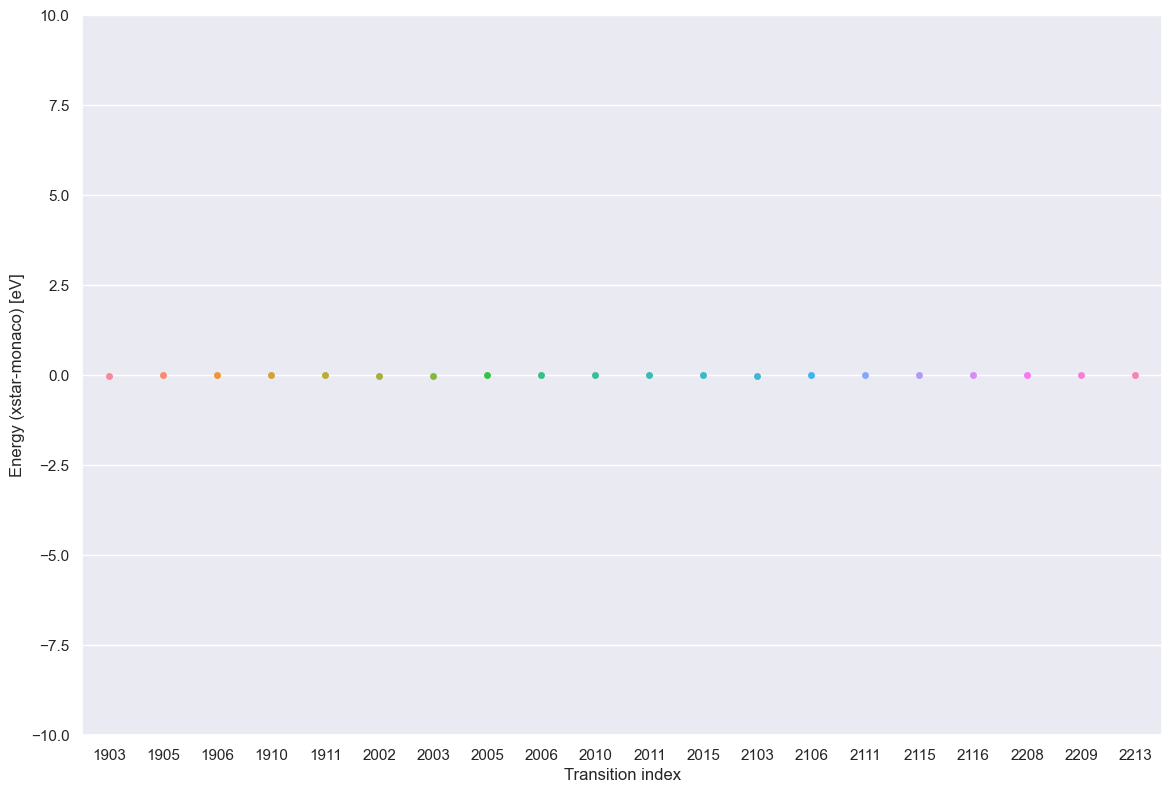

In [12]:
fi     = figure(figsize=(12,8),dpi=100)
subplots_adjust(left=0.075, bottom=0.075, right=0.975, top=0.975)
axis           ([0e+0,3e+3,-1e+1,+1e+1])
swarmplot      (x=Si01_Transition_Index[40:60], y=Si01_Transition_Energy[40:60])
xlabel         ("Transition index")
ylabel         ("Energy (xstar-monaco) [eV]")
savefig        ("/Users/tanimoto/github/atomicdatabase/figure/03.png")

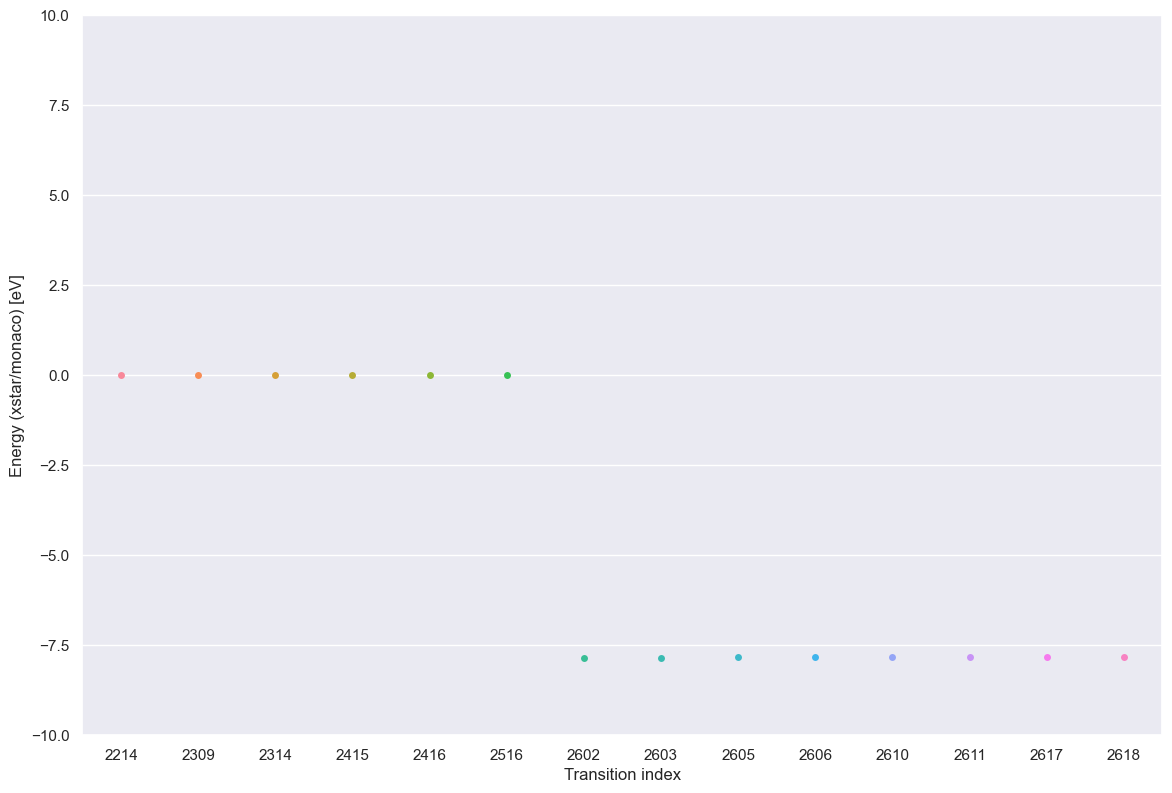

In [15]:
fi     = figure(figsize=(12,8),dpi=100)
subplots_adjust(left=0.075, bottom=0.075, right=0.975, top=0.975)
axis           ([0e+0,3e+3,-1e+1,+1e+1])
swarmplot      (x=Si01_Transition_Index[60:80], y=Si01_Transition_Energy[60:80])
xlabel         ("Transition index")
ylabel         ("Energy (xstar-monaco) [eV]")
savefig        ("/Users/tanimoto/github/atomicdatabase/figure/04.png")

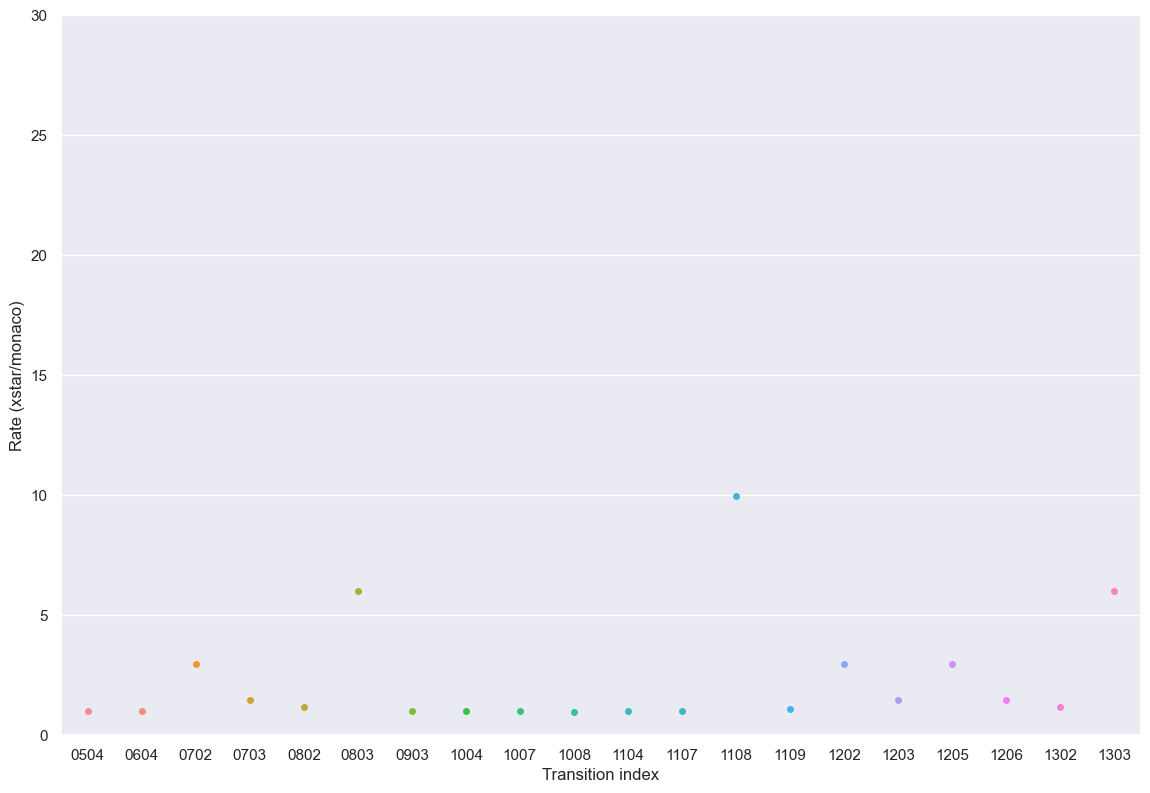

In [28]:
fi     = figure(figsize=(12,8),dpi=100)
subplots_adjust(left=0.075, bottom=0.075, right=0.975, top=0.975)
axis           ([0e+0,3e+3,+0e+0,+3e+1])
swarmplot      (x=Si01_Transition_Index[0:20], y=Si01_Transition_Rate[0:20])
xlabel         ("Transition index")
ylabel         ("Rate (xstar/monaco)")
savefig        ("/Users/tanimoto/github/atomicdatabase/figure/05.png")

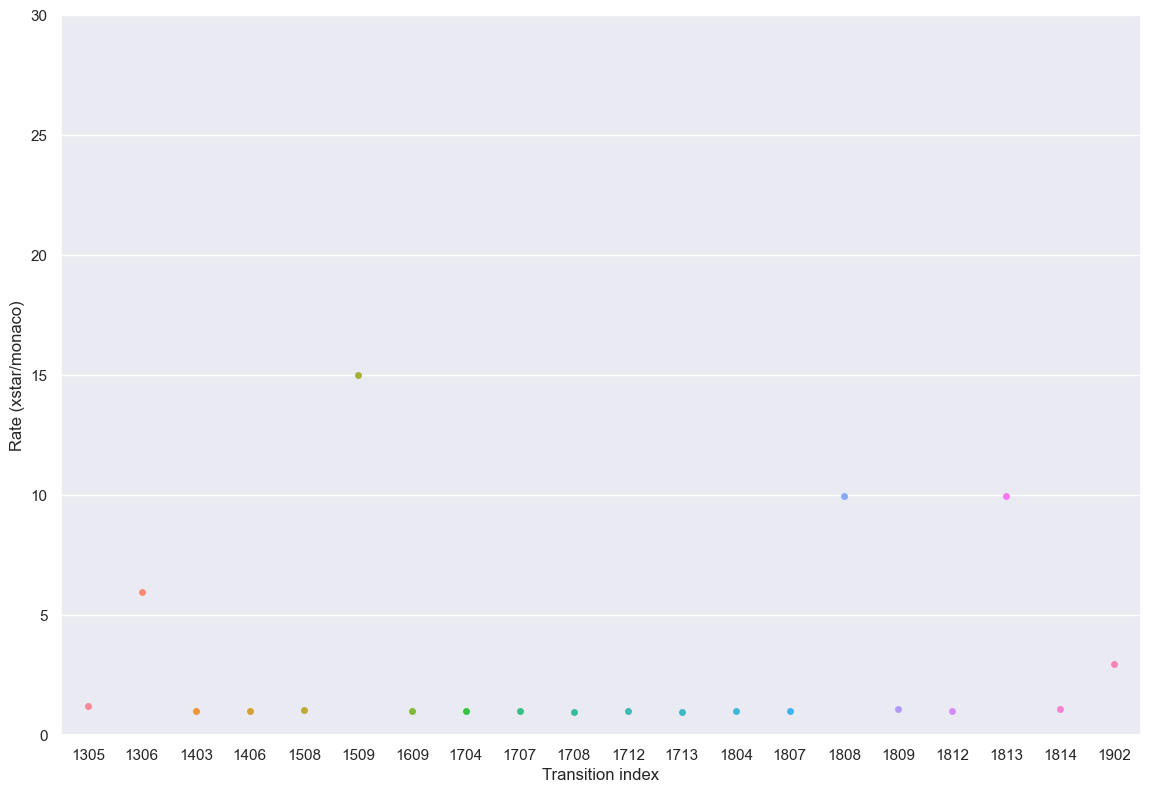

In [27]:
fi     = figure(figsize=(12,8),dpi=100)
subplots_adjust(left=0.075, bottom=0.075, right=0.975, top=0.975)
axis           ([0e+0,3e+3,+0e+0,+3e+1])
swarmplot      (x=Si01_Transition_Index[20:40], y=Si01_Transition_Rate[20:40])
xlabel         ("Transition index")
ylabel         ("Rate (xstar/monaco)")
savefig        ("/Users/tanimoto/github/atomicdatabase/figure/06.png")

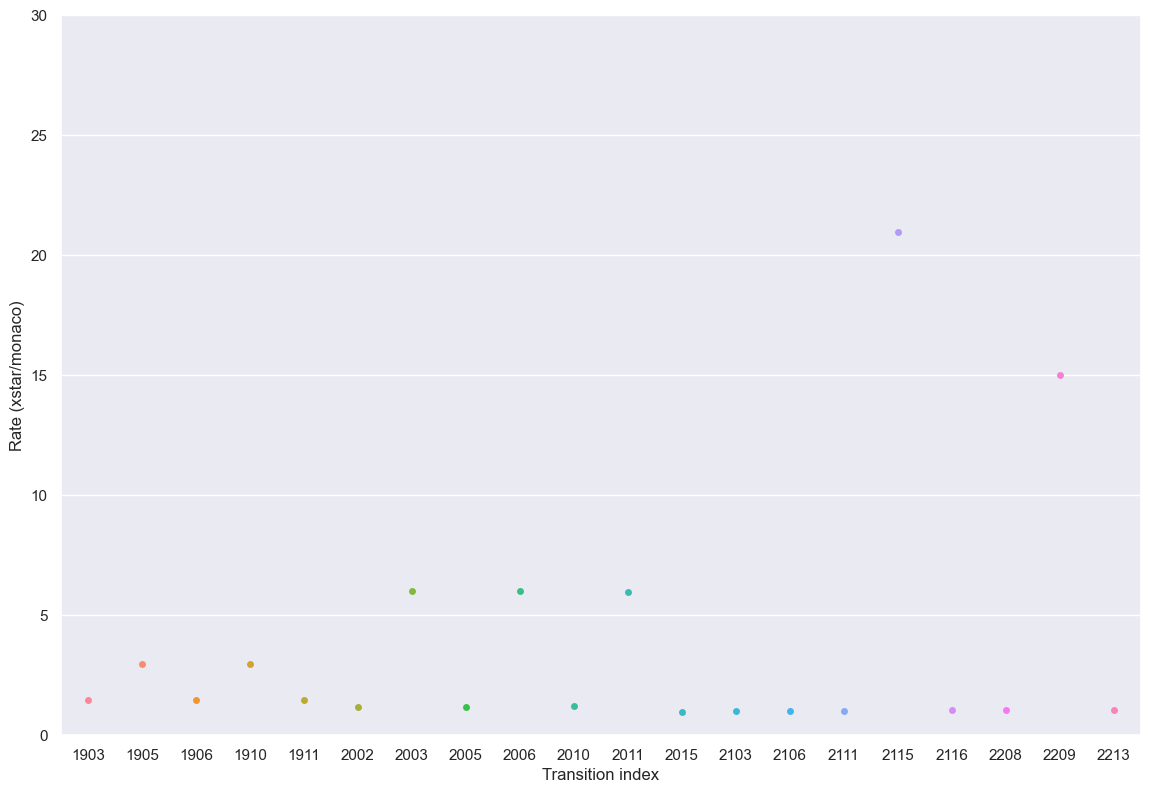

In [26]:
fi     = figure(figsize=(12,8),dpi=100)
subplots_adjust(left=0.075, bottom=0.075, right=0.975, top=0.975)
axis           ([0e+0,3e+3,+0e+0,+3e+1])
swarmplot      (x=Si01_Transition_Index[40:60], y=Si01_Transition_Rate[40:60])
xlabel         ("Transition index")
ylabel         ("Rate (xstar/monaco)")
savefig        ("/Users/tanimoto/github/atomicdatabase/figure/07.png")

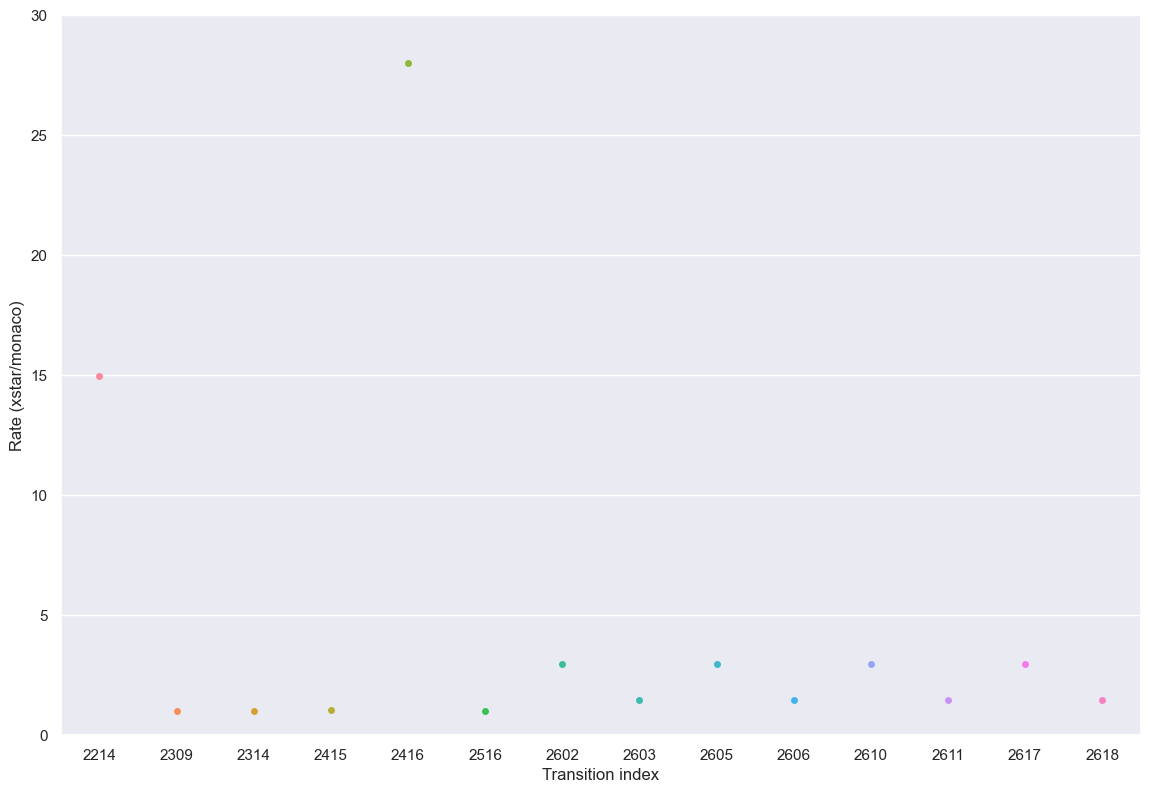

In [29]:
fi     = figure(figsize=(12,8),dpi=100)
subplots_adjust(left=0.075, bottom=0.075, right=0.975, top=0.975)
axis           ([0e+0,3e+3,+0e+0,+3e+1])
swarmplot      (x=Si01_Transition_Index[60:80], y=Si01_Transition_Rate[60:80])
xlabel         ("Transition index")
ylabel         ("Rate (xstar/monaco)")
savefig        ("/Users/tanimoto/github/atomicdatabase/figure/08.png")

# Si02 Recombination

In [30]:
Atom_Si02_Recombination = {}
Atom_Si02_Recombination["Temperature"] = logspace(5,10,100)
Atom_Si02_Recombination["Rate"]        = atomdb.get_ionrec_rate(Te_in=logspace(5,10,100), Z=14, z1=13)[1]
Atom_Si02_Recombination

{'Temperature': array([1.00000000e+05, 1.12332403e+05, 1.26185688e+05, 1.41747416e+05,
        1.59228279e+05, 1.78864953e+05, 2.00923300e+05, 2.25701972e+05,
        2.53536449e+05, 2.84803587e+05, 3.19926714e+05, 3.59381366e+05,
        4.03701726e+05, 4.53487851e+05, 5.09413801e+05, 5.72236766e+05,
        6.42807312e+05, 7.22080902e+05, 8.11130831e+05, 9.11162756e+05,
        1.02353102e+06, 1.14975700e+06, 1.29154967e+06, 1.45082878e+06,
        1.62975083e+06, 1.83073828e+06, 2.05651231e+06, 2.31012970e+06,
        2.59502421e+06, 2.91505306e+06, 3.27454916e+06, 3.67837977e+06,
        4.13201240e+06, 4.64158883e+06, 5.21400829e+06, 5.85702082e+06,
        6.57933225e+06, 7.39072203e+06, 8.30217568e+06, 9.32603347e+06,
        1.04761575e+07, 1.17681195e+07, 1.32194115e+07, 1.48496826e+07,
        1.66810054e+07, 1.87381742e+07, 2.10490414e+07, 2.36448941e+07,
        2.65608778e+07, 2.98364724e+07, 3.35160265e+07, 3.76493581e+07,
        4.22924287e+07, 4.75081016e+07, 5.3366992

In [31]:
Temperature = []
Rate        = []

with open("/Users/tanimoto/github/atomicdatabase/database/monaco/Si/Si02.rates") as file:
    for line in file.readlines():
        line         = line.split()
        Temperature += [11604.525*float(line[1])]
        Rate        += [float(line[2])]

Monaco_Si02_Recombination = DataFrame({"Temperature":Temperature, "Rate":Rate})
Monaco_Si02_Recombination.head()

,Temperature,Rate
0,11604.525000,1.304410e-10
1,14609.284658,1.128090e-10
2,18391.895627,9.747880e-11
3,23154.044551,8.416260e-11
4,29149.290302,7.260630e-11


In [33]:
Recombination = read_csv("/Users/tanimoto/github/atomicdatabase/database/xstar/Si/Si02_Recombination02.tsv",sep="\t")
Temperature   = []
Rate          = []

for T in logspace(0,5,100):
    Temperature += [10000*T]
    Rate        += [Recombination["r1"][0]/T**Recombination["r2"][0]]

Xstar_Si02_Recombination = DataFrame({"Temperature":Temperature, "Rate":Rate})
Xstar_Si02_Recombination

FileNotFoundError: [Errno 2] No such file or directory: '/Users/tanimoto/github/atomicdatabase/database/xstar/Si/Si02_Recombination02.tsv'

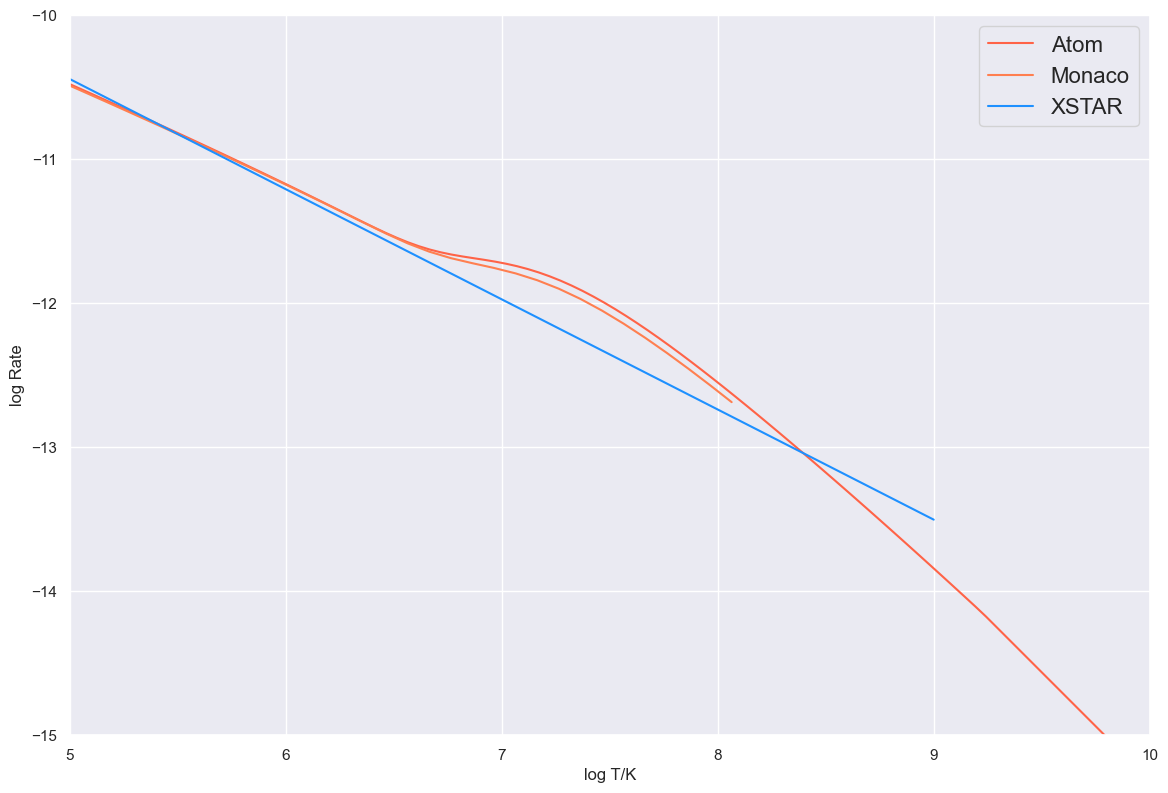

In [14]:
fi     = figure(figsize=(12,8),dpi=100)
subplots_adjust(left=0.075, bottom=0.075, right=0.975, top=0.975)
axis           ([+4e+0,+10e+0,-15e+0,-9e+0])
plot           (log10(  Atom_Si02_Recombination["Temperature"]), log10(  Atom_Si02_Recombination["Rate"]), color="tomato"    , label="Atom"  )
plot           (log10(Monaco_Si02_Recombination["Temperature"]), log10(Monaco_Si02_Recombination["Rate"]), color="coral"     , label="Monaco")
plot           (log10( Xstar_Si02_Recombination["Temperature"]), log10( Xstar_Si02_Recombination["Rate"]), color="dodgerblue", label="XSTAR" )
legend         (fontsize=16, loc="upper right")
xlabel         ("log T/K")
ylabel         ("log Rate")
savefig        ("/Users/tanimoto/github/atomicdatabase/figure/09.png")